In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from scoreoperator.diffusion.sde import SDEFactory
from scoreoperator.utils.data import DataFactory
from scoreoperator.diffusion.bridge import DiffusionBridge

In [89]:
x0 = DataFactory.create("butterfly", {"name": "archon_apollinus"})
xT = DataFactory.create("butterfly", {"name": "battus_polydamas"})

x_shape = (100, 2)
t_shape = (100, )
w_shape = (100, 100, 2)
rng_key = jr.PRNGKey(42)

bridge = DiffusionBridge(    
    "kunita_flow", 
    {
        "x0": x0, 
        "xT": xT, 
        "T": 1.0,
        "k_alpha": 0.1,
        "k_sigma": 0.3
    }
)

bridge.project(x_shape, t_shape, w_shape)

xs, ts, _ = bridge.solve_forward_sde(rng_key)
xs = xs + x0.eval(x_shape)[None, :, :]
print(xs.shape)

(100, 100, 2)


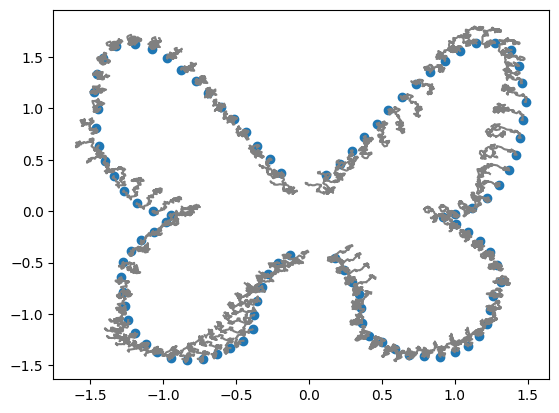

In [90]:
fig = plt.figure()

plt.scatter(xs[0, :, 0], xs[0, :, 1], color="tab:blue")

for i in range(xs.shape[1]):
    plt.plot(xs[:, i, 0], xs[:, i, 1], color="grey")

In [91]:
score_model = lambda t, x: - x / t

ys = bridge.solve_reverse_bridge(rng_key, score_model, x_shape, t_shape, w_shape, xT = xT - x0)

ys = ys + x0.eval(x_shape)[None, :, :]
print(ys.shape)

(101, 100, 2)


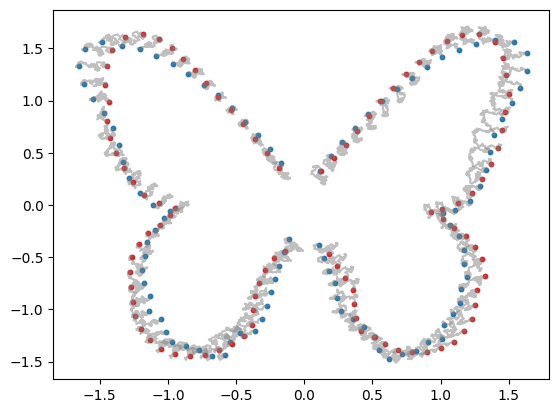

In [92]:
fig = plt.figure()

plt.scatter(ys[0, :, 0], ys[0, :, 1], color="tab:blue", s=10)

for i in range(ys.shape[1]):
    plt.plot(ys[:, i, 0], ys[:, i, 1], color="grey", alpha=0.5)
    
plt.scatter(ys[-1, :, 0], ys[-1, :, 1], color="tab:red", s=10)